# Abrir os dados do gist

In [ ]:
import pandas as pd

dados = pd.read_csv('https://gist.githubusercontent.com/caiohamamura/9decb1605e9b10e2118c44920b8f29a7/raw/999c08ff8d3653fc3f141089acaeabb5eed85977/diabetes_dataset.csv')

dados

,Unnamed: 0,Age,Sex,Ethnicity,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,...,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate,Physical_Activity_Level,Dietary_Intake_Calories,Alcohol_Consumption,Smoking_Status,Family_History_of_Diabetes,Previous_Gestational_Diabetes
0,0,58,Female,White,35.8,83.4,123.9,10.9,152,114,...,50.2,99.2,37.5,7.2,Moderate,1538,Moderate,Never,0,1
1,1,48,Male,Asian,24.1,71.4,183.7,12.8,103,91,...,62.0,146.4,88.5,6.1,Moderate,2653,Moderate,Current,0,1
2,2,34,Female,Black,25.0,113.8,142.0,14.5,179,104,...,32.1,164.1,56.2,6.9,Low,1684,Heavy,Former,1,0
3,3,62,Male,Asian,32.7,100.4,167.4,8.8,176,118,...,41.1,84.0,34.4,5.4,Low,3796,Moderate,Never,1,0
4,4,27,Female,Asian,33.5,110.8,146.4,7.1,122,97,...,53.9,92.8,81.9,7.4,Moderate,3161,Heavy,Current,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,45,Female,Asian,39.4,114.0,76.2,13.4,109,82,...,60.3,88.7,19.1,6.1,Low,3582,NaN,Former,1,1
9996,9996,41,Female,Asian,21.0,71.3,77.1,12.9,154,72,...,72.3,200.0,37.1,3.5,Low,2206,NaN,Never,1,1
9997,9997,50,Female,Asian,29.0,106.3,97.5,4.9,122,61,...,69.8,156.1,85.8,4.9,High,3175,Heavy,Former,1,1
9998,9998,62,Female,White,27.3,119.9,89.0,11.5,99,115,...,74.2,110.9,25.3,5.2,High,3478,Moderate,Never,1,0


# Remover coluna que não faz sentido

In [ ]:
dados.drop(columns=['Unnamed: 0'], inplace = True)

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            10000 non-null  int64  
 1   Sex                            10000 non-null  object 
 2   Ethnicity                      10000 non-null  object 
 3   BMI                            10000 non-null  float64
 4   Waist_Circumference            10000 non-null  float64
 5   Fasting_Blood_Glucose          10000 non-null  float64
 6   HbA1c                          10000 non-null  float64
 7   Blood_Pressure_Systolic        10000 non-null  int64  
 8   Blood_Pressure_Diastolic       10000 non-null  int64  
 9   Cholesterol_Total              10000 non-null  float64
 10  Cholesterol_HDL                10000 non-null  float64
 11  Cholesterol_LDL                10000 non-null  float64
 12  GGT                            10000 non-null  

In [ ]:
# Retorna todas as colunas presentes
dados.columns

Index(['Age', 'Sex', 'Ethnicity', 'BMI', 'Waist_Circumference',
       'Fasting_Blood_Glucose', 'HbA1c', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Cholesterol_Total', 'Cholesterol_HDL',
       'Cholesterol_LDL', 'GGT', 'Serum_Urate', 'Physical_Activity_Level',
       'Dietary_Intake_Calories', 'Alcohol_Consumption', 'Smoking_Status',
       'Family_History_of_Diabetes', 'Previous_Gestational_Diabetes'],
      dtype='object')

In [ ]:
# Escolhe apenas as colunas do tipo inteiro e float
colunas_numericas = dados.select_dtypes(include=['int64', 'float64']).columns
colunas_numericas

Index(['Age', 'BMI', 'Waist_Circumference', 'Fasting_Blood_Glucose', 'HbA1c',
       'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic',
       'Cholesterol_Total', 'Cholesterol_HDL', 'Cholesterol_LDL', 'GGT',
       'Serum_Urate', 'Dietary_Intake_Calories', 'Family_History_of_Diabetes',
       'Previous_Gestational_Diabetes'],
      dtype='object')

In [ ]:
# Conta quantos valores únicos cada coluna tem
dados[colunas_numericas].nunique()

,0
Age,50
BMI,216
Waist_Circumference,501
Fasting_Blood_Glucose,1301
HbA1c,111
Blood_Pressure_Systolic,90
Blood_Pressure_Diastolic,60
Cholesterol_Total,1499
Cholesterol_HDL,501
Cholesterol_LDL,1301


In [ ]:
# Baseado nisso iremos escolher como numéricas as colunas
# inteiro e float que tiverem mais de dois valores únicos
colunas_numericas = dados.select_dtypes(include=['int64', 'float64']).columns
colunas_numericas = colunas_numericas[dados[colunas_numericas].nunique() > 2]
colunas_numericas

Index(['Age', 'BMI', 'Waist_Circumference', 'Fasting_Blood_Glucose', 'HbA1c',
       'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic',
       'Cholesterol_Total', 'Cholesterol_HDL', 'Cholesterol_LDL', 'GGT',
       'Serum_Urate', 'Dietary_Intake_Calories'],
      dtype='object')

In [ ]:
# As colunas categóricas são as que forem do tipo object (texto)
colunas_categoricas = dados.select_dtypes(include=['object']).columns
colunas_categoricas

Index(['Sex', 'Ethnicity', 'Physical_Activity_Level', 'Alcohol_Consumption',
       'Smoking_Status'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import MinMaxScaler

dados2 = pd.get_dummies(dados, columns=colunas_categoricas, drop_first=True)

scaler_entrada = MinMaxScaler()
dados2[colunas_numericas] = scaler_entrada.fit_transform(dados2[colunas_numericas])

# Remover colunas que já dizem se é diabético ou não (é o que queremos predizer)
dados_entrada = dados2.drop(columns=['HbA1c', 'Fasting_Blood_Glucose'])
dados_entrada.head()

,Age,BMI,Waist_Circumference,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Total,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate,...,Previous_Gestational_Diabetes,Sex_Male,Ethnicity_Black,Ethnicity_Hispanic,Ethnicity_White,Physical_Activity_Level_Low,Physical_Activity_Level_Moderate,Alcohol_Consumption_Moderate,Smoking_Status_Former,Smoking_Status_Never
0,0.775510,0.804651,0.268,0.696629,0.915254,0.318667,0.404,0.224615,0.305556,0.84,...,1,False,False,False,True,False,True,True,False,True
1,0.571429,0.260465,0.028,0.146067,0.525424,0.744000,0.640,0.587692,0.872222,0.62,...,1,True,False,False,False,False,True,True,False,False
2,0.285714,0.302326,0.876,1.000000,0.745763,0.740000,0.042,0.723846,0.513333,0.78,...,0,False,True,False,False,True,False,False,True,False
3,0.857143,0.660465,0.608,0.966292,0.983051,0.222667,0.222,0.107692,0.271111,0.48,...,0,True,False,False,False,True,False,True,False,True
4,0.142857,0.697674,0.816,0.359551,0.627119,0.354667,0.478,0.175385,0.798889,0.88,...,0,False,False,False,False,False,True,False,False,False


In [ ]:
scaler_saida = MinMaxScaler()

# HbA1c é a coluna de saída
dados_saida = dados[['HbA1c']]
dados_saida_escalado = pd.DataFrame(scaler_saida.fit_transform(dados_saida))

# Escalamos a coluna de saída separadamente para permitir retornar os valores
# inversos quando fizermos a predição
dados_saida_escalado

,0
0,0.627273
1,0.800000
2,0.954545
3,0.436364
4,0.281818
...,...
9995,0.854545
9996,0.809091
9997,0.081818
9998,0.681818


In [ ]:
from re import X
from sklearn.model_selection import train_test_split

seed = 42

X_train, X_test, y_train, y_test = train_test_split(dados_entrada, dados_saida_escalado, test_size=0.15, random_state=seed)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=seed)



In [ ]:
import torch
import torch.nn as nn

x_train_tensor = torch.tensor(X_train.values.astype('float32'), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.astype('float32'), dtype=torch.float32)
x_val_tensor = torch.tensor(X_val.values.astype('float32'), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values.astype('float32'), dtype=torch.float32)
x_test_tensor = torch.tensor(X_test.values.astype('float32'), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.astype('float32'), dtype=torch.float32)


In [ ]:
x_train_tensor.shape[1]

22

In [ ]:
class Modelo(nn.Module):
  def __init__(self):
    super(Modelo, self).__init__()
    self.camada1 = nn.Linear(x_train_tensor.shape[1], 16)
    self.camada2 = nn.Linear(16, 16)
    self.camada3 = nn.Linear(16, 1)

  def forward(self, x):
    x = torch.relu(self.camada1(x))
    x = torch.relu(self.camada2(x))
    x = torch.sigmoid(self.camada3(x))
    return x

In [ ]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

modelo = Modelo()
fn_loss = nn.MSELoss()
optimizer = torch.optim.Adam(modelo.parameters(), lr=0.001)

In [ ]:
train_loss = []
val_loss = []
epoch = 100
melhor_loss = float('inf')
melhor_modelo = None

for i in range(epoch):
  optimizer.zero_grad()
  pred = modelo(x_train_tensor)
  loss = fn_loss(pred, y_train_tensor)
  loss.backward()
  loss_val = fn_loss(modelo(x_val_tensor), y_val_tensor)
  train_loss.append(loss.item())
  val_loss.append(loss_val.item())
  if loss_val.item() < melhor_loss:
    melhor_loss = loss_val.item()
    melhor_modelo = modelo.state_dict()
  optimizer.step()
  print(f'Epoch: {i} - Loss: {loss.item()} - Loss Val: {loss_val.item()}')

Epoch: 0 - Loss: 0.08409527689218521 - Loss Val: 0.08240972459316254
Epoch: 1 - Loss: 0.08403299748897552 - Loss Val: 0.08234807103872299
Epoch: 2 - Loss: 0.08397579193115234 - Loss Val: 0.0822913646697998
Epoch: 3 - Loss: 0.08392385393381119 - Loss Val: 0.08223988860845566
Epoch: 4 - Loss: 0.08387699723243713 - Loss Val: 0.0821935161948204
Epoch: 5 - Loss: 0.08383570611476898 - Loss Val: 0.08215101063251495
Epoch: 6 - Loss: 0.08380000293254852 - Loss Val: 0.08211341500282288
Epoch: 7 - Loss: 0.08376948535442352 - Loss Val: 0.08208128809928894
Epoch: 8 - Loss: 0.08374441415071487 - Loss Val: 0.08205342292785645
Epoch: 9 - Loss: 0.08372384309768677 - Loss Val: 0.0820300281047821
Epoch: 10 - Loss: 0.08370722830295563 - Loss Val: 0.08201177418231964
Epoch: 11 - Loss: 0.08369389176368713 - Loss Val: 0.08199874311685562
Epoch: 12 - Loss: 0.08368311077356339 - Loss Val: 0.08198927342891693
Epoch: 13 - Loss: 0.08367471396923065 - Loss Val: 0.08198250085115433
Epoch: 14 - Loss: 0.0836684256792

<Axes: >

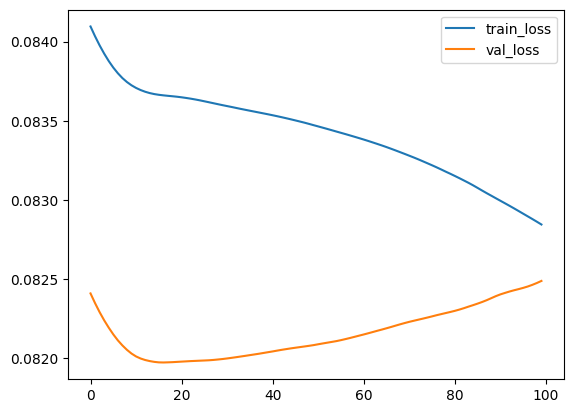

In [ ]:
import seaborn as sns

sns.lineplot(train_loss, label='train_loss')
sns.lineplot(val_loss, label='val_loss')

In [ ]:
# Restaurar melhor modelo
modelo.load_state_dict(melhor_modelo)

<All keys matched successfully>

In [ ]:
predicao_final = modelo(x_test_tensor)
predicao_final

tensor([[0.5078],
        [0.5094],
        [0.4731],
        ...,
        [0.4991],
        [0.5066],
        [0.4790]], grad_fn=<SigmoidBackward0>)

In [ ]:
# Utilizar o escalador inverso para retornar os valores de
# hemoglobina glicada predito
scaler_saida.inverse_transform(predicao_final.detach().numpy())

array([[9.585945],
       [9.60339 ],
       [9.204242],
       ...,
       [9.490419],
       [9.572717],
       [9.269546]], dtype=float32)

In [ ]:
scaler_saida.inverse_transform(y_test_tensor.detach().numpy())

array([[14.299999],
       [13.3     ],
       [14.      ],
       ...,
       [ 9.099999],
       [ 8.3     ],
       [10.1     ]], dtype=float32)